# CNN Visualization [[lab4](https://mdig.agh.edu.pl/dokuwiki/doku.php?id=teaching:data_science:dnn:vis#cnn_visualization)]

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from keras import models
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input, decode_predictions
from keras.preprocessing.image import load_img
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.scorecam import Scorecam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from matplotlib import cm

In [2]:
# Load alredy pre-trained model
model = VGG16(weights="imagenet", include_top=True)
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

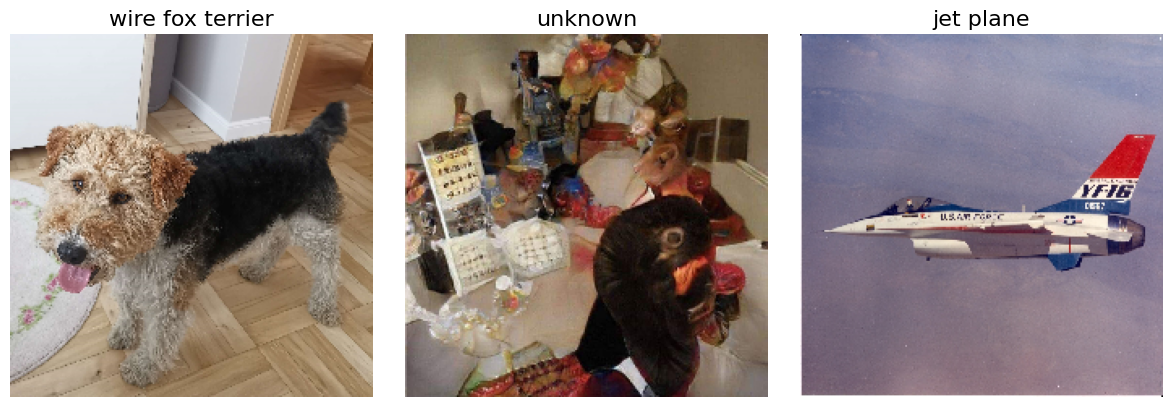

In [3]:
# Assign image titles for your images
image_titles = [
    "wire fox terrier",
    "unknown",
    "jet plane",
]

# Load images and reshape them
img1 = load_img(r"images/wirefoxterrier.jpg", target_size=(224, 224))
img2 = load_img(r"images/unknown.jpg", target_size=(224, 224))
img3 = load_img(r"images/yf16.bmp", target_size=(224, 224))
# We resize the images into size 224 x 224, as the model prefers those sizes. However, if your images are smaller, you can change those values a little bit.

# Convert them to a Numpy array
images = np.asarray(
    [
        np.array(img1),
        np.array(img2),
        np.array(img3),
    ]
)

# Preparing input data for VGG16
X = preprocess_input(images)


# Rendering
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
for i, title in enumerate(image_titles):
    ax[i].set_title(title, fontsize=16)
    ax[i].imshow(images[i])
    ax[i].axis("off")
plt.tight_layout()
plt.show()

In [4]:
# Predict the output (probabilities) of the layer, corresponding to an image

# Feed images into the network and see the results (use "predict" function)
preds = model.predict(X)
# Find the best class (use argmax or argsort function)
best_class = np.argmax(preds, axis=-1)

# Decode prediction based on Imagenet dataset dictionary. Each umerical class is assigned to a real-life label
for i, title in enumerate(image_titles):
    print(f"Predicted ({title}):", decode_predictions(preds, top=3)[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
Predicted (wire fox terrier): [('n02095570', 'Lakeland_terrier', np.float32(0.7947367)), ('n02096051', 'Airedale', np.float32(0.14298965)), ('n02095314', 'wire-haired_fox_terrier', np.float32(0.060430717))]
Predicted (unknown): [('n04462240', 'toyshop', np.float32(0.2542813)), ('n02776631', 'bakery', np.float32(0.06950219)), ('n10148035', 'groom', np.float32(0.053422034))]
Predicted (jet plane): [('n04552348', 'warplane', np.float32(0.6639837)), ('n02690373', 'airliner', np.float32(0.19776618)), ('n04592741', 'wing', np.float32(0.050416835))]


## Visualizing heatmaps

In [5]:
def visualise_heatmap(map, images):
  f, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
  for i, title in enumerate(image_titles):
      heatmap = np.uint8(cm.jet(map[i])[..., :3] * 255)
      ax[i].set_title(title, fontsize=16)
      ax[i].imshow(images[i])
      ax[i].imshow(heatmap, cmap='jet', alpha=0.5)
      ax[i].axis('off')
  plt.tight_layout()
  plt.show()

## GradCAM

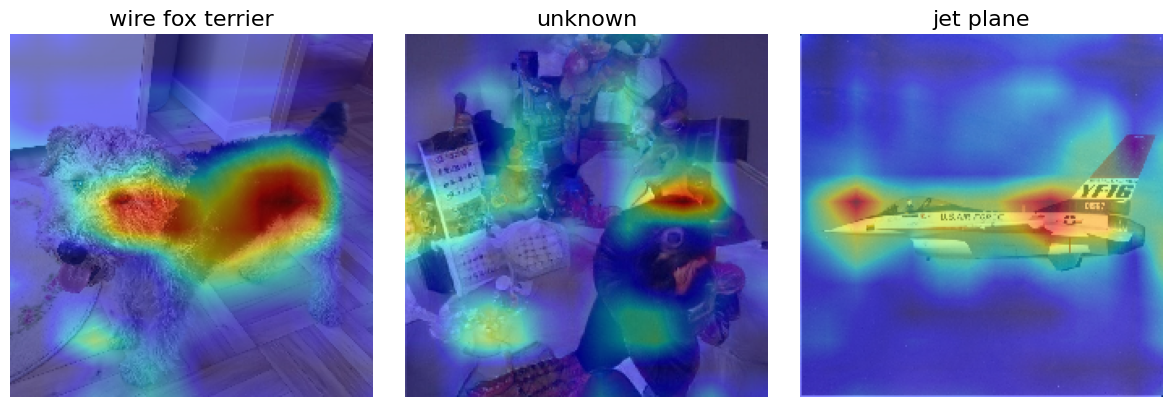

In [6]:
replace2linear = ReplaceToLinear()
score = CategoricalScore(list(best_class))

gradcam = Gradcam(model, model_modifier=replace2linear, clone=True)

cam = gradcam(score, X, penultimate_layer=-1)

visualise_heatmap(cam, images)

## GradCAM++

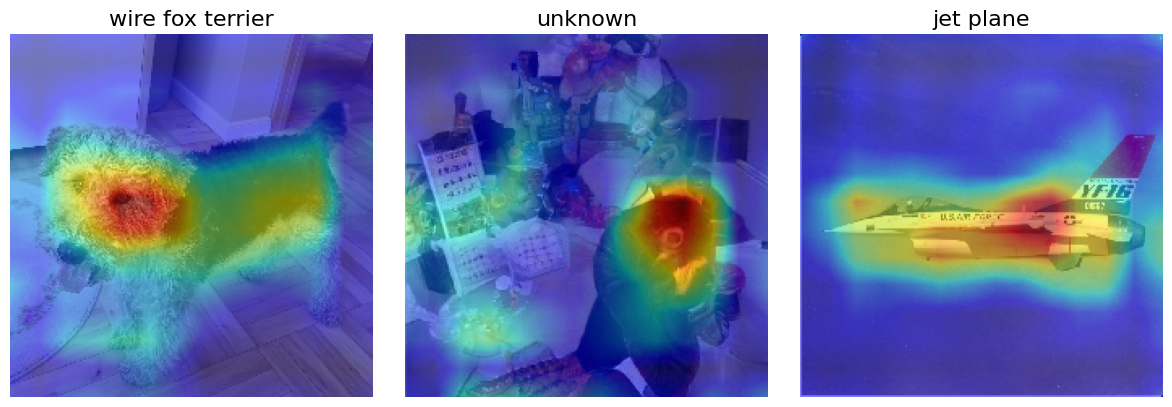

In [7]:
gradcam = GradcamPlusPlus(model, model_modifier=replace2linear, clone=True)

cam = gradcam(score, X, penultimate_layer=-1)

visualise_heatmap(cam, images)

## ScoreCAM

c:\Users\robert\Desktop\paug-agh-2025\.venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 224, 224, 3))',)
  warnings.warn(msg)


48/48 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step


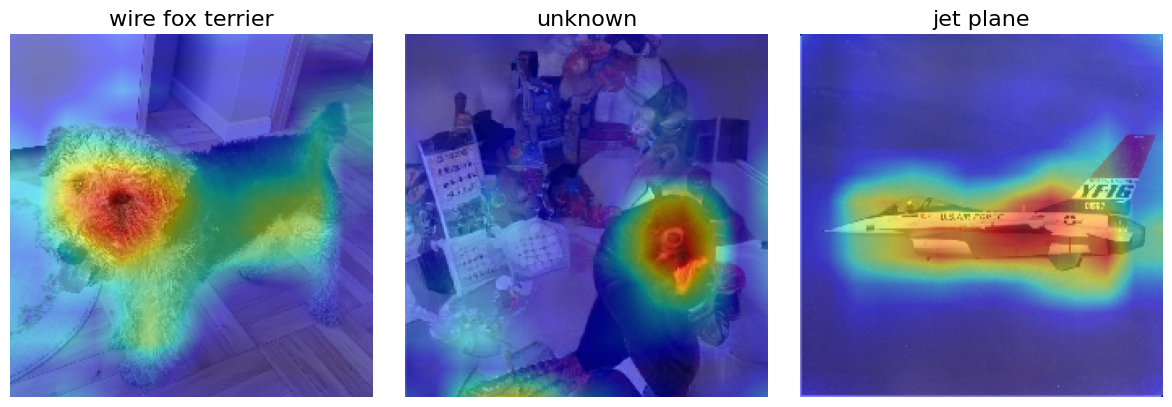

In [8]:
scorecam = Scorecam(model)
cam = scorecam(score, X, penultimate_layer=-1)
visualise_heatmap(cam,images)

## Saliency Maps

c:\Users\robert\Desktop\paug-agh-2025\.venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)


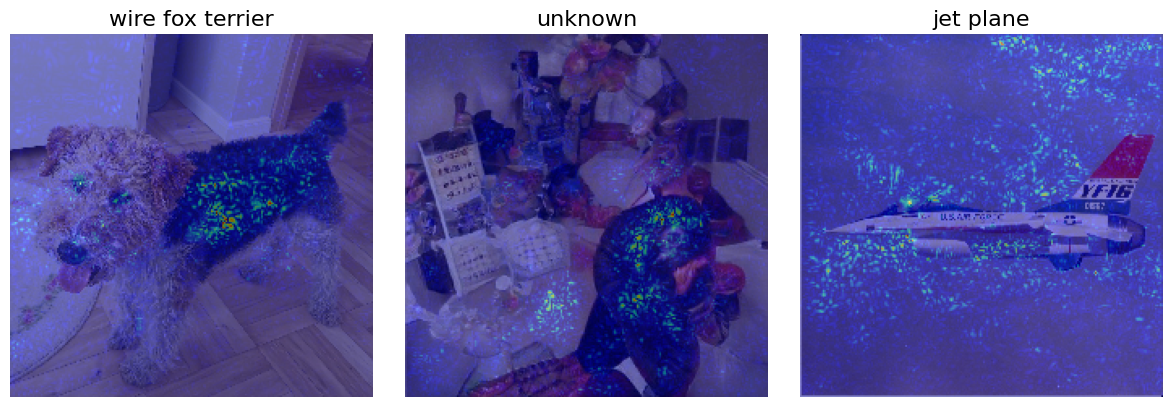

In [9]:
saliency = Saliency(model, model_modifier=replace2linear, clone=True)
saliency_map = saliency(score, X)
visualise_heatmap(saliency_map, images)

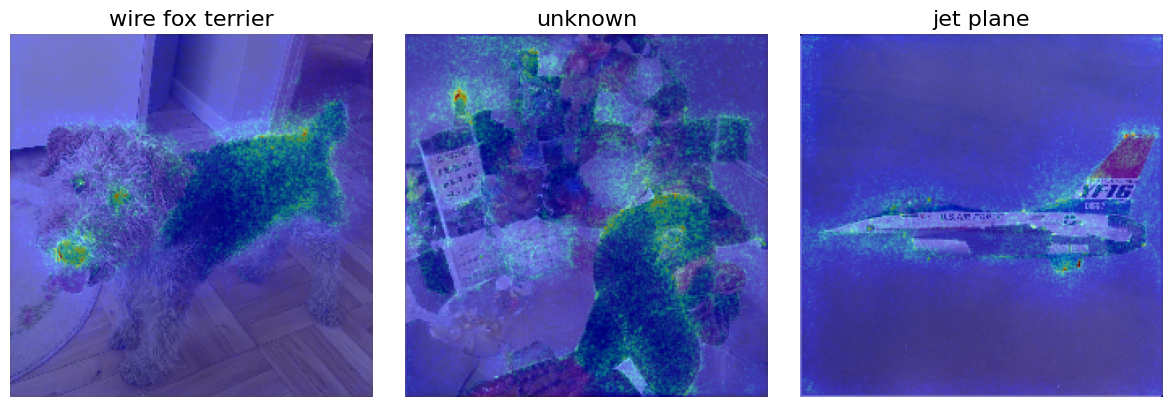

In [10]:
saliency_map = saliency(score, X, smooth_samples=20, smooth_noise=0.20)
visualise_heatmap(saliency_map, images)

## Visualizing intermediate activations

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step


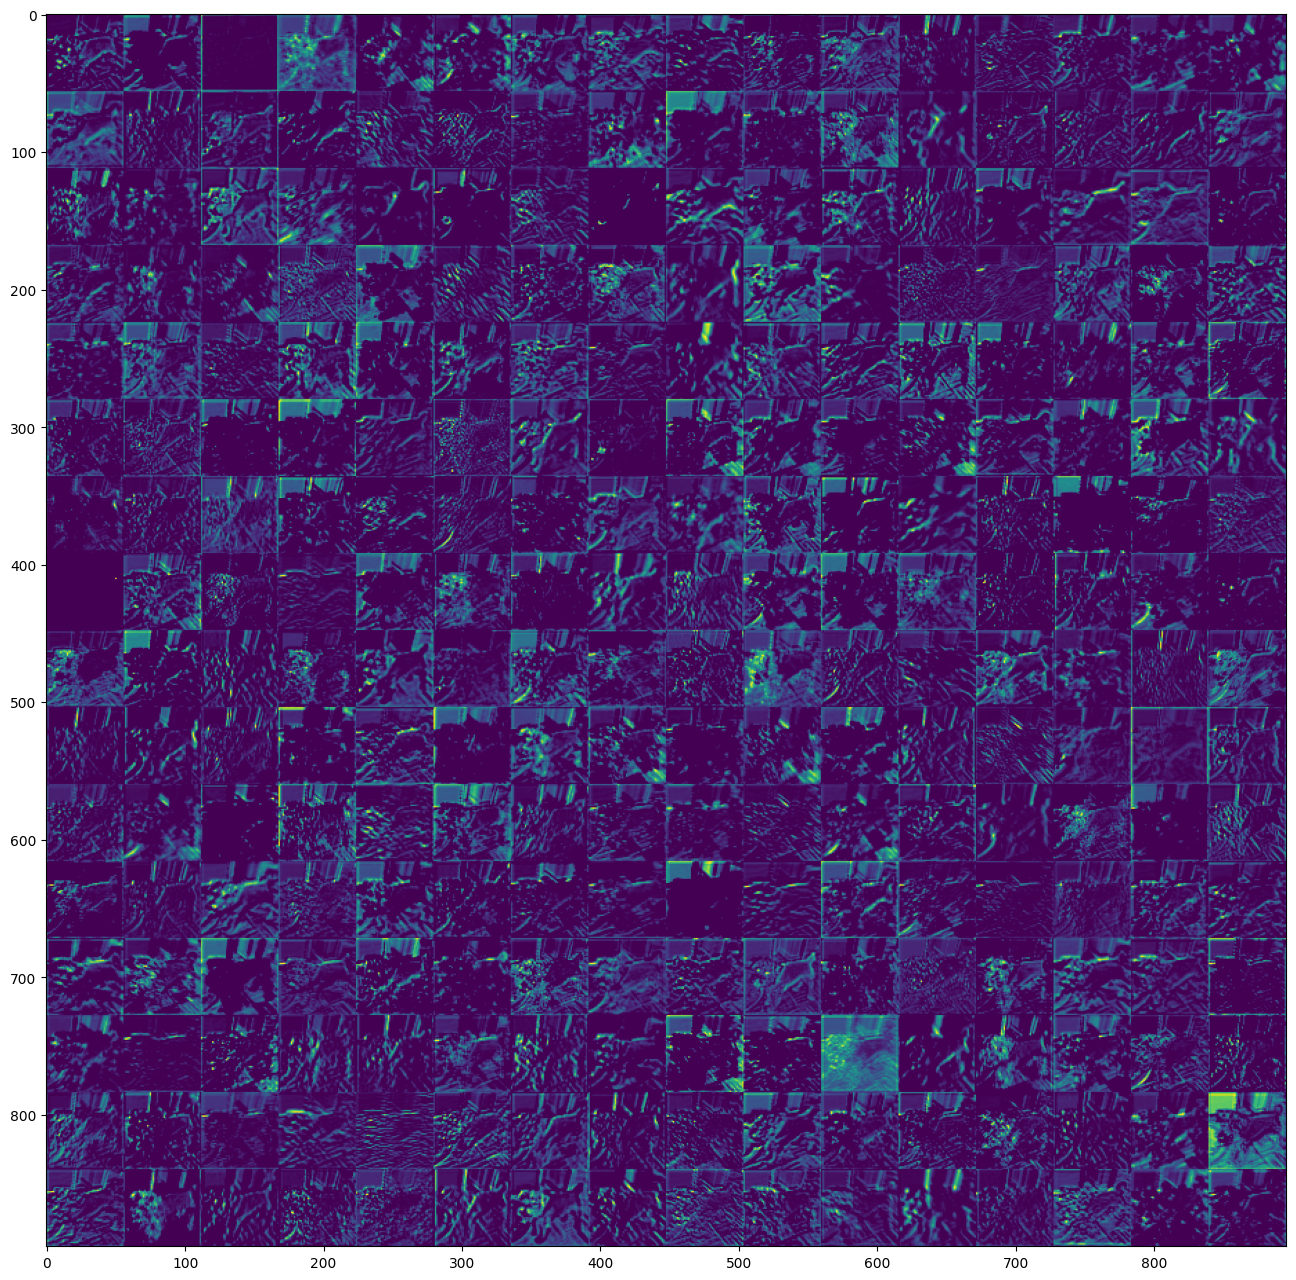

In [11]:
# Loop through the model defined in the beginning to access outputs of individual layers
layer_outputs = [layer.output for layer in model.layers]
activation_model = models.Model(model.input, layer_outputs)

# Take one image and reshape it into size (1,224,224,3)
X_reshaped = np.expand_dims(images[0], axis=0)
print(X_reshaped.shape)
# Use the predict function on the activation model to get the intermediate activations
activations = activation_model.predict(X_reshaped)

layer_names = []
for layer in model.layers[:-1]:
    layer_names.append(layer.name)

images_per_row = 16
for layer_name, layer_activation in zip(layer_names, activations):
    # Specify the name of the layer that you want to see. Choose one name from the model summary we printed in the beginning
    if layer_name == "block3_conv1":
        number_of_feature_maps = layer_activation.shape[-1]
        feature_map_shape = layer_activation.shape[1]
        n_cols = number_of_feature_maps // images_per_row
        display_grid = np.zeros(
            (feature_map_shape * n_cols, images_per_row * feature_map_shape)
        )
        for col in range(n_cols):
            for row in range(images_per_row):
                channel_image = layer_activation[0, :, :, col * images_per_row + row]
                channel_image /= np.max(channel_image)
                display_grid[
                    col * feature_map_shape : (col + 1) * feature_map_shape,
                    row * feature_map_shape : (row + 1) * feature_map_shape,
                ] = channel_image
        scale = 1.0 / feature_map_shape
        plt.figure(
            figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0])
        )
        plt.imshow(display_grid, aspect="auto", cmap="viridis")